Due to the large size of the ResNet18 model and Tiny Imagenet dataset, I have not sent these.

To run the codes in this file, you must place the resnet18-f37072fd.pth file and tiny-imagenet-200 folder next to the q2.ipynb file.

# سوال دوم - بخش اول - زیربخش دوم

### الف و ب

In [ ]:
import torch
import numpy as np
from torchvision.models import resnet18
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from pathlib import Path
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from PIL import Image

MODEL_PATH = "resnet18-f37072fd.pth"
DATA_PATH = "tiny-imagenet-200"

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = resnet18(weights=None)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Model loaded from", MODEL_PATH)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(Path(DATA_PATH) / "train", transform=transform)
val_dataset = datasets.ImageFolder(Path(DATA_PATH) / "val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)

print("Train images size:", len(train_dataset))
print("Val images size:", len(val_dataset))
print("Number of classes:", len(train_dataset.classes))

Using device: cpu
Model loaded from ../Model Weights/resnet18-f37072fd.pth
Train images size: 100000
Val images size: 10000
Number of classes: 200


### ج

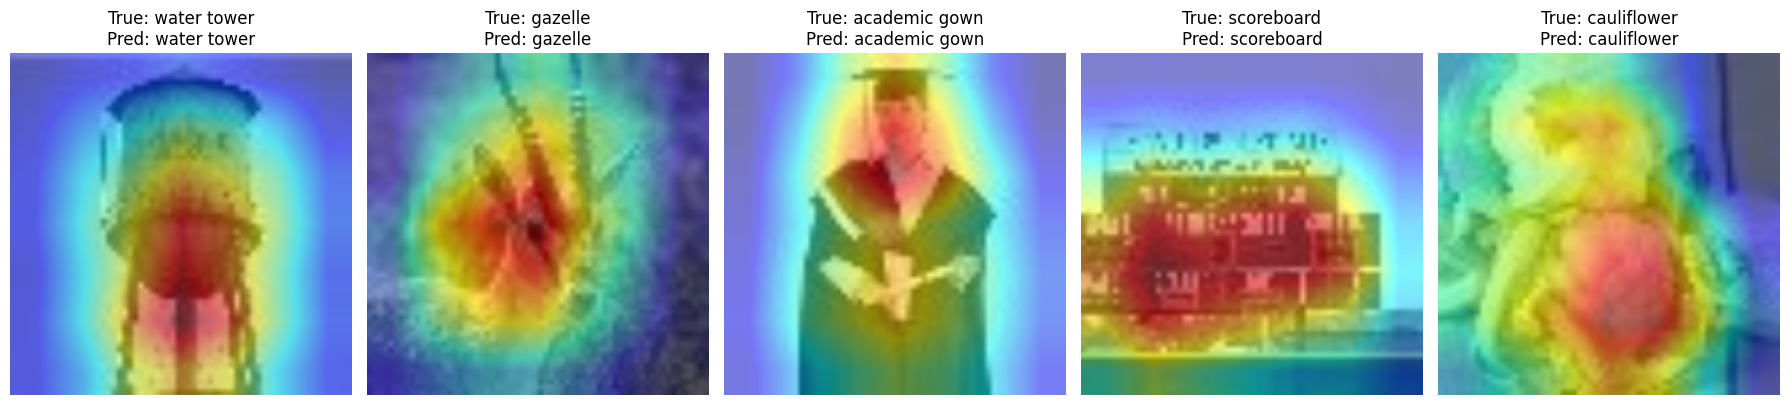

In [104]:
feature_maps = None
grads = None

def save_feature_maps(module, inp, out):
    global feature_maps
    feature_maps = out

def save_grads(module, grad_in, grad_out):
    global grads
    grads = grad_out[0]

model.layer4[-1].register_forward_hook(save_feature_maps)
model.layer4[-1].register_full_backward_hook(save_grads)

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img.cpu() * std + mean
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def make_gradcam(img, class_index):
    model.zero_grad()
    out = model(img)

    out[0, class_index].backward()

    weights = grads.mean(dim=(2, 3), keepdim=True)
    
    grad_cam = (weights * feature_maps).sum(dim=1).squeeze()
    grad_cam = torch.relu(grad_cam)

    grad_cam = grad_cam.detach().cpu().numpy()
    grad_cam = cv2.resize(grad_cam, (224, 224))
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

DATA_PATH = Path("tiny-imagenet-200")

classId_to_name = {}
with open(DATA_PATH / "words.txt", "r") as words_file:
    for line in words_file:
        classId, names = line.strip().split("\t")
        classId_to_name[classId] = names.split(",")[0]


val_samples = []
with open(DATA_PATH / "val" / "val_annotations.txt", "r") as val_file:
    for line in val_file:
        img_name, classId = line.split()[:2]
        img_path = DATA_PATH / "val" / "images" / img_name
        val_samples.append((img_path, classId))

val_indexes = torch.randperm(len(val_samples), generator = torch.Generator().manual_seed(69)).tolist()

class_names = ResNet18_Weights.IMAGENET1K_V1.meta["categories"]

selected_samples = []

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes = axes.ravel()

count = 0

for idx in val_indexes:
    img_path, true_classId = val_samples[idx]

    img_pil = Image.open(img_path).convert("RGB")
    input_img = transform(img_pil).unsqueeze(0).to(device)

    out = model(input_img)
    pred = out.argmax(dim=1)

    pred_name = class_names[pred.item()]
    true_name = classId_to_name[true_classId]

    if pred_name != true_name:
        continue

    grad_cam = make_gradcam(input_img, pred.item())
    img = unnormalize(input_img[0])

    heatmap = cv2.applyColorMap(np.uint8(255 * grad_cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255

    result = 0.5 * img + 0.5 * heatmap

    selected_samples.append((input_img.detach().clone(), pred.item(), true_name))

    axes[count].imshow(result)
    axes[count].set_title(f"True: {true_name}\nPred: {class_names[pred.item()]}", fontsize=12)
    axes[count].axis("off")

    count += 1
    if count == 5:
        break

plt.tight_layout()
plt.show()

### د

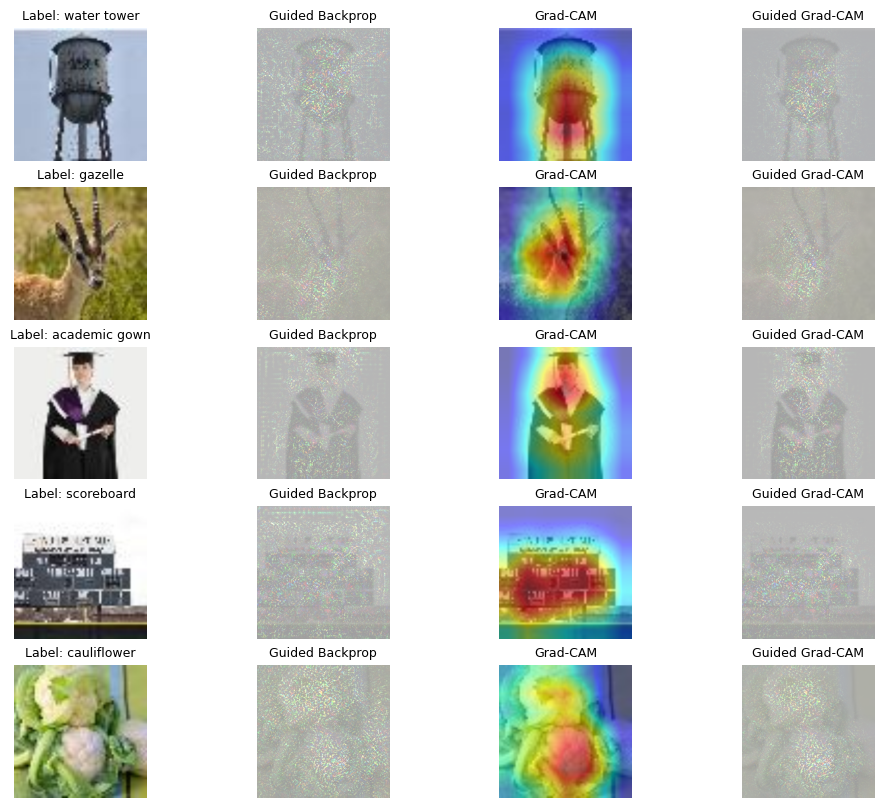

In [107]:
def make_guided_backprop(img, class_index):
    img = img.clone().detach().requires_grad_(True)

    model.zero_grad()
    out = model(img)
    out[0, class_index].backward()

    gbp = img.grad[0].detach().cpu()
    gbp = torch.relu(gbp)

    gbp = gbp.permute(1, 2, 0).numpy()
    gbp = gbp / (gbp.max() + 1e-8)

    return gbp

def make_guided_gradcam(img, class_index):
    gbp = make_guided_backprop(img, class_index)
    grad_cam = make_gradcam(img, class_index)

    guided_cam = gbp * grad_cam[..., None]
    guided_cam = guided_cam / (guided_cam.max() + 1e-8)

    return guided_cam

fig, axes = plt.subplots(5, 4, figsize=(12, 10))

for i, (input_img, pred_idx, true_name) in enumerate(selected_samples):
    input_img = input_img.to(device)
    img = unnormalize(input_img[0])

    grad_cam = make_gradcam(input_img, pred_idx)
    heatmap = cv2.applyColorMap(np.uint8(255 * grad_cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255
    gradcam_img = 0.5 * img + 0.5 * heatmap

    gbp = make_guided_backprop(input_img, pred_idx)
    faint_img_bp = 0.1 * img + 0.8 * np.ones_like(img) * 0.8
    gbp_vis = faint_img_bp + (gbp - gbp.mean())
    gbp_vis = np.clip(gbp_vis, 0, 1)

    guided_cam = make_guided_gradcam(input_img, pred_idx)
    faint_img_ggc = 0.1 * img + 0.8 * np.ones_like(img) * 0.8
    guided_vis = faint_img_ggc + (guided_cam - guided_cam.mean())
    guided_vis = np.clip(guided_vis, 0, 1)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Label: {class_names[pred_idx]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gbp_vis)
    axes[i, 1].set_title("Guided Backprop", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(gradcam_img)
    axes[i, 2].set_title("Grad-CAM", fontsize=9)
    axes[i, 2].axis("off")

    axes[i, 3].imshow(guided_vis)
    axes[i, 3].set_title("Guided Grad-CAM", fontsize=9)
    axes[i, 3].axis("off")

plt.show()

# سوال دوم - بخش دوم - زیربخش دوم

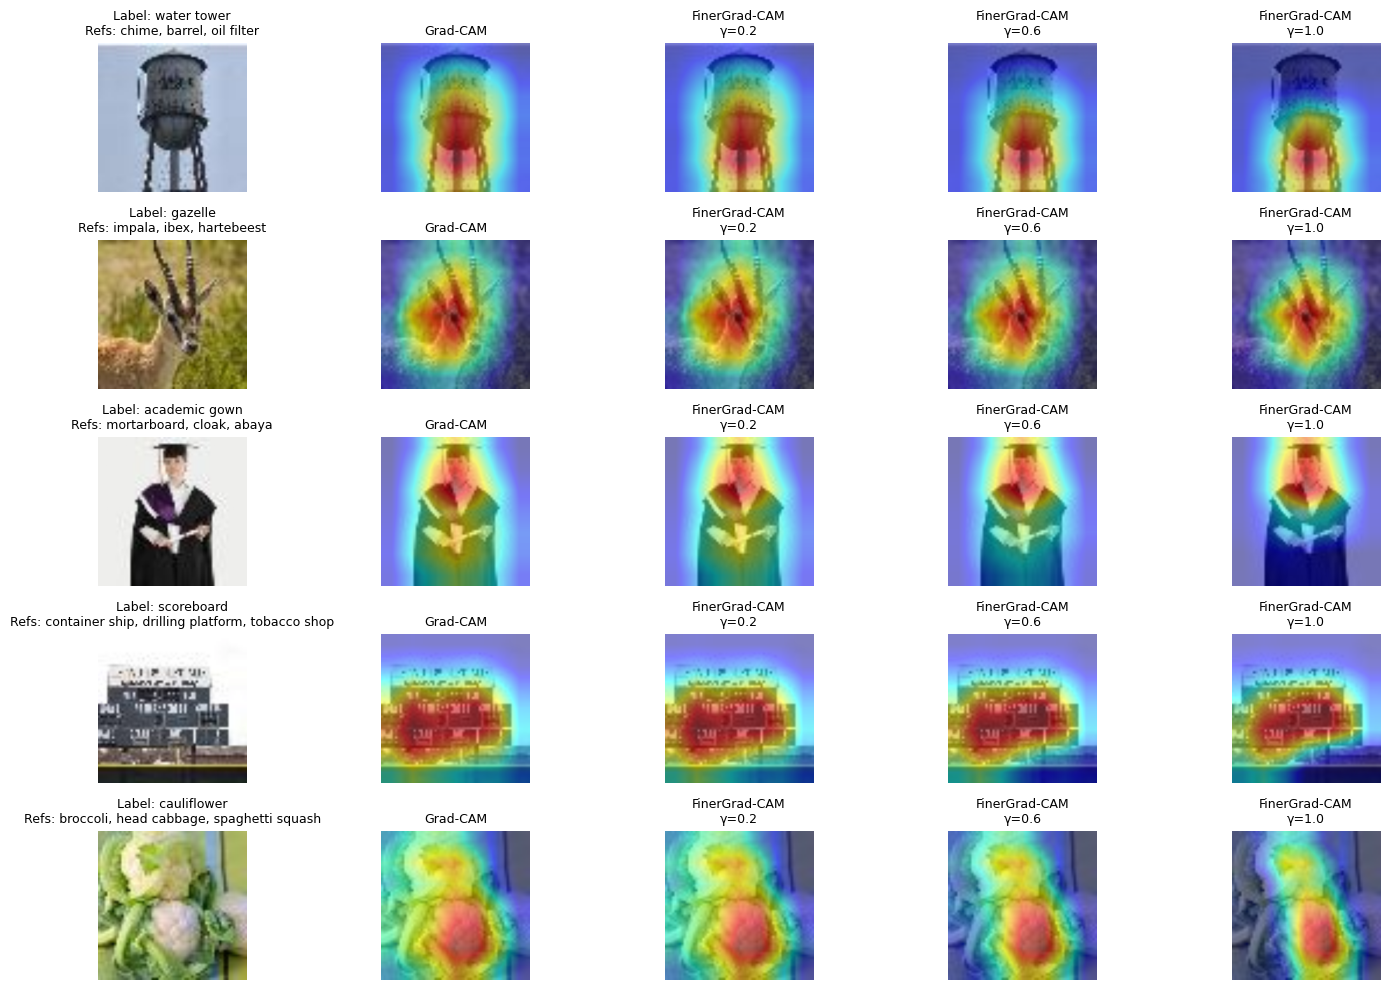

In [111]:
def make_finer_gradcam(img, target_class, ref_classes, gamma):
    model.zero_grad()
    out = model(img)

    ref_avg = out[0, ref_classes].mean()
    score = out[0, target_class] - gamma * ref_avg

    score.backward()

    weights = grads.mean(dim=(2, 3), keepdim=True)
    
    finer_cam = (weights * feature_maps).sum(dim=1).squeeze()
    finer_cam = torch.relu(finer_cam)

    finer_cam = finer_cam.detach().cpu().numpy()
    finer_cam = cv2.resize(finer_cam, (224, 224))
    finer_cam = (finer_cam - finer_cam.min()) / (finer_cam.max() - finer_cam.min() + 1e-8)

    return finer_cam

gammas = [0.2, 0.6, 1.0]

fig, axes = plt.subplots(5, 5, figsize=(15, 10))

for i, (input_img, target_class, true_name) in enumerate(selected_samples):
    input_img = input_img.to(device)

    out = model(input_img)
    top_classes = out[0].topk(4).indices.tolist()

    ref_classes = [cls for cls in top_classes if cls != target_class][:3]

    img = unnormalize(input_img[0])

    gradcam = make_gradcam(input_img, target_class)
    heatmap = cv2.applyColorMap(np.uint8(255 * gradcam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255
    gradcam_img = 0.5 * img + 0.5 * heatmap

    ref_names = ", ".join([class_names[c] for c in ref_classes])

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Label: {class_names[target_class]}\nRefs: {ref_names}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gradcam_img)
    axes[i, 1].set_title("Grad-CAM", fontsize=9)
    axes[i, 1].axis("off")

    for j, gamma in enumerate(gammas):
        finer_cam = make_finer_gradcam(input_img, target_class, ref_classes, gamma)

        heatmap = cv2.applyColorMap(np.uint8(255 * finer_cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255
        finer_img = 0.5 * img + 0.5 * heatmap

        axes[i, j + 2].imshow(finer_img)
        axes[i, j + 2].set_title(f"FinerGrad-CAM\nγ={gamma}", fontsize=9)
        axes[i, j + 2].axis("off")

plt.tight_layout()
plt.show()